# Is PyMatching's correlated-matching reweight equivalent to Fowler (2013)?

Notebook version of `scripts/test_fowler_vs_conditional_reweighting.py`. Full write-up:
[`docs/fowler_vs_conditional_reweighting.md`](../docs/fowler_vs_conditional_reweighting.md).

Given a first-pass-matched edge (cylinder) **ν** and a partner edge **µ** that shares a DEM fault
mechanism with ν, two second-pass reweight rules:

* **Conditional** (the PyMatching-fork / `DecodingGraph.analytical_cm...` rule):
  $$P_\text{cond}(\mu\mid\nu) = \frac{\mathrm{corr}(\mu,\nu)}{\mathrm{occ}(\nu)}$$
  pairwise joint over the marginal, both **XOR-combined** (odd parity).

* **Fowler** (2013, [arXiv:1310.0863](https://arxiv.org/abs/1310.0863)): believe ν with certainty →
  take all mechanisms whose component is ν, **uniformly scale so they sum to 1**, then boost µ by the
  shared-mechanism mass:
  $$P_\text{fowler}(\mu\mid\nu) = \frac{\sum_{m\,\ni\,\{\mu,\nu\}} p_m}{\sum_{m\,\ni\,\nu} p_m}
  = \frac{S_\text{both}(\mu,\nu)}{Z_\nu}.$$

Both map $p_\text{imp}\to w=\log\frac{1-p_\text{imp}}{p_\text{imp}}$ and take the min weight over matched
neighbours — **identical** except for $p_\text{imp}$. This notebook measures whether they coincide
(formula and decode level) and compares both to PyMatching's built-in `enable_correlations`.

In [6]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import stim, pymatching

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.decoding_graph import DecodingGraph
from NeuralCM.two_pass_correlated_matching import TwoPassCorrelatedMatching

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Helpers — extract the DEM fault mechanisms

`build_mechanisms` parses every DEM error into its component edges (mirroring
`DecodingGraph._build_line_graph_edges`) and accumulates the two Fowler ingredients:
`Z_sum[e] = Σ pₘ` over mechanisms touching edge `e` (Fowler's **sum** normaliser) and
`S_both[(a,b)] = Σ pₘ` over mechanisms touching both (the shared-mechanism joint).

In [7]:
def build_mechanisms(dem, graph):
    # Returns (mechanisms, Z_sum, S_both):
    #   mechanisms : list of (p, tuple(edge_idx))
    #   Z_sum      : [n_edges] sum of p over mechanisms whose components include the edge
    #   S_both     : dict (a,b) -> sum of p over mechanisms whose components include both a,b
    P2I = graph.pair_to_idx_matrix
    mechanisms, Z_sum, S_both = [], np.zeros(graph.n_dec_edges, dtype=np.float64), {}
    for inst in dem.flattened():
        if inst.type != "error":
            continue
        p = inst.args_copy()[0]
        comps, cur = [], []
        for t in inst.targets_copy():
            if t.is_separator():
                if cur:
                    comps.append(cur); cur = []
            elif t.is_relative_detector_id():
                cur.append(t.val)
        if cur:
            comps.append(cur)
        edge_ids = []
        for comp in comps:
            u = comp[0] if len(comp) > 0 else -1
            v = comp[1] if len(comp) > 1 else -1
            idx = P2I[u, v]
            if idx >= 0:
                edge_ids.append(int(idx))
        edge_ids = tuple(sorted(set(edge_ids)))
        if not edge_ids:
            continue
        mechanisms.append((p, edge_ids))
        for e in edge_ids:
            Z_sum[e] += p
        for i in range(len(edge_ids)):
            for j in range(i + 1, len(edge_ids)):
                a, b = edge_ids[i], edge_ids[j]
                S_both[(a, b)] = S_both.get((a, b), 0.0) + p
                S_both[(b, a)] = S_both.get((b, a), 0.0) + p
    return mechanisms, Z_sum, S_both

def implied_p_conditional(mu, nu, e_idx, graph):
    return graph.initial_corr_tracer[e_idx] / max(graph.base_p[nu], 1e-12)

def implied_p_fowler(mu, nu, S_both, Z_sum):
    return S_both.get((mu, nu), 0.0) / max(Z_sum[nu], 1e-12)

def fowler_corr_array(graph, S_both):
    # S_both mapped onto the graph's line-edge ordering (Fowler joint per correlated pair).
    src, dst = graph.line_edge_index
    return np.array([S_both.get((int(src[k]), int(dst[k])), 0.0)
                     for k in range(graph.n_line_edges)], dtype=np.float32)

def build_setup(d, p, rounds=0):
    rounds = d if rounds == 0 else rounds
    circ = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=d, rounds=rounds,
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p)
    dem = decompose_errors_for_stim_surface_code_coords(
        circ.detector_error_model(decompose_errors=False))
    graph = DecodingGraph.from_dem(dem)
    mechanisms, Z_sum, S_both = build_mechanisms(dem, graph)
    return circ, dem, graph, mechanisms, Z_sum, S_both

print("helpers ready")

helpers ready


## Configuration

The conditional-vs-Fowler decode disagreements scale like the O(p) normaliser gap: at `P = 1e-2`
they appear within ~10⁵ shots (measured ≈9×10⁻⁴ per shot); at `P = 4e-4` (the α-analysis regime)
they are vanishingly rare, so large `SHOTS` budgets are needed to see any.

Decoding is **chunked** (`CHUNK` shots at a time), so `SHOTS` can be set arbitrarily large without
memory issues. Runtime: the two-pass second stage is a per-shot Python loop over the non-trivial
shots — at `P=4e-4` roughly 15% of shots — so expect ~1-2 min per 10⁶ shots at this `p` (and
~2 min per 10⁵ shots at `p=1e-2`, where nearly every shot is non-trivial).

In [8]:
D       = 5
ROUNDS  = 0          # 0 -> use distance
P       = 4e-4
SHOTS   = 100_000_000  # total budget; decoding is CHUNKED so any size is memory-safe
CHUNK   = 1_000_000    # shots per chunk (keeps the decode arrays small)
SEED    = 12345
BYPASS  = 0          # skip shots with <= this many detections (0 = process all non-trivial)

circ, dem, graph, mechanisms, Z_sum, S_both = build_setup(D, P, ROUNDS)
print(f"d={D} p={P:g} rounds={ROUNDS or D} | detectors={dem.num_detectors} "
      f"edges={graph.n_dec_edges} mechanisms={len(mechanisms)} correlated_pairs={graph.n_line_edges}")

d=5 p=0.0004 rounds=5 | detectors=120 edges=502 mechanisms=1677 correlated_pairs=1175


## Part 1 — formula-level comparison on every correlated pair

Compare $P_\text{cond}$ and $P_\text{fowler}$ for every ordered correlated pair, and separately check
the two ingredients: the **joint** (`corr` vs `S_both`) and the **normaliser** (`occ` vs `Z_sum`).

In [9]:
src, dst = graph.line_edge_index
diffs, rels, rows = [], [], []
for k in range(graph.n_line_edges):
    a, b = int(src[k]), int(dst[k])
    for mu, nu in ((a, b), (b, a)):
        pc = implied_p_conditional(mu, nu, k, graph)
        pf = implied_p_fowler(mu, nu, S_both, Z_sum)
        diffs.append(abs(pf - pc)); rels.append(abs(pf - pc) / max(pc, 1e-12))
        rows.append((mu, nu, pc, pf))
diffs, rels = np.array(diffs), np.array(rels)

occ_vs_Zsum = np.abs(graph.base_p - Z_sum)
corr_vs_Sboth = np.array([abs(graph.initial_corr_tracer[k]
                              - S_both.get((int(src[k]), int(dst[k])), 0.0))
                          for k in range(graph.n_line_edges)])

print("Formula: P_cond(mu|nu) vs P_fowler(mu|nu) over all correlated pairs")
print(f"  |P_fowler - P_cond|:  max={diffs.max():.3e}  mean={diffs.mean():.3e}")
print(f"  relative difference:  max={rels.max():.3e}  mean={rels.mean():.3e}")
print(f"  |corr - S_both|  (joint)     : max={corr_vs_Sboth.max():.3e}   <- identical => 0")
print(f"  |occ  - Z_sum|   (normaliser): max={occ_vs_Zsum.max():.3e}   <- the whole difference")
print("\n  largest-discrepancy pairs (mu, nu, P_cond, P_fowler):")
for o in np.argsort(-diffs)[:6]:
    mu, nu, pc, pf = rows[o]
    print(f"    mu={mu:4d} nu={nu:4d}  P_cond={pc:.4e}  P_fowler={pf:.4e}")

Formula: P_cond(mu|nu) vs P_fowler(mu|nu) over all correlated pairs
  |P_fowler - P_cond|:  max=2.724e-04  mean=4.536e-05
  relative difference:  max=2.829e-03  mean=7.559e-04
  |corr - S_both|  (joint)     : max=0.000e+00   <- identical => 0
  |occ  - Z_sum|   (normaliser): max=1.190e-05   <- the whole difference

  largest-discrepancy pairs (mu, nu, P_cond, P_fowler):
    mu= 477 nu= 418  P_cond=2.0340e-01  P_fowler=2.0313e-01
    mu=   7 nu=  73  P_cond=2.0340e-01  P_fowler=2.0313e-01
    mu= 167 nu= 163  P_cond=2.0340e-01  P_fowler=2.0314e-01
    mu= 317 nu= 323  P_cond=2.0340e-01  P_fowler=2.0314e-01
    mu= 472 nu= 395  P_cond=7.6243e-02  P_fowler=7.6028e-02
    mu=  74 nu=  12  P_cond=7.6243e-02  P_fowler=7.6028e-02


**Expectation:** the joint is identical (`|corr - S_both| = 0` — each correlated pair shares one
mechanism, so odd-parity = sum), and the only difference is the normaliser
$Z_\nu \to \mathrm{occ}(\nu)$, giving $P_\text{cond}/P_\text{fowler} = Z_\nu/\mathrm{occ}(\nu) =
1 + \mathcal{O}(Np) \ge 1$: the conditional boosts µ marginally harder.

## Part 2 — decode-level comparison on real shots

Both rules run through the *same* tested two-pass class (`TwoPassCorrelatedMatching`, deterministic
`decode_batch`), differing only in the reweight ingredients:

* **conditional** → default `occ = base_p`, `corr = initial_corr_tracer`;
* **Fowler** → `occ = Z_sum` (sum normaliser), `corr = S_both` (same joint).

Comparing per-shot rather than re-implementing avoids degenerate-matching tie-break noise (~10⁻⁴)
between `decode()` and `decode_batch()`.

In [10]:
mwpm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=False)
cm_builtin = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)
dec_cond = TwoPassCorrelatedMatching(dem, alpha=1.0, bypass_threshold=BYPASS, graph=graph)
dec_fowler = TwoPassCorrelatedMatching(
    dem, alpha=1.0, bypass_threshold=BYPASS, graph=graph,
    occ=Z_sum.astype(np.float32), corr=fowler_corr_array(graph, S_both))

# Chunked streaming: sample+decode CHUNK shots at a time so peak memory stays bounded
# regardless of SHOTS. (Passing one giant multi-GB bool array into decode_batch makes
# the pybind bool->uint8 conversion fail with a TypeError.)
sampler = circ.compile_detector_sampler(seed=SEED)
names = ["MWPM", "CM built-in (alpha=1)", "CM conditional 2-pass", "CM Fowler 2-pass"]
err = dict.fromkeys(names, 0)
dis_keys = [("conditional vs Fowler  ", 2, 3), ("conditional vs built-in", 2, 1),
            ("Fowler      vs built-in", 3, 1), ("built-in    vs MWPM    ", 1, 0)]
dis = {k: 0 for k, _, _ in dis_keys}
done = 0
t0 = time.time()
while done < SHOTS:
    n = min(CHUNK, SHOTS - done)
    det, obs = sampler.sample(shots=n, separate_observables=True)
    det = det.astype(np.uint8)          # native dtype for the pybind decode_batch path
    obs = obs[:, 0].astype(np.uint8)
    preds = [mwpm.decode_batch(det)[:, 0],
             cm_builtin.decode_batch(det, enable_correlations=True, alpha=1.0)[:, 0],
             dec_cond.decode_batch(det)[:, 0],
             dec_fowler.decode_batch(det)[:, 0]]
    for name, pr in zip(names, preds):
        err[name] += int((pr != obs).sum())
    for k, a, b in dis_keys:
        dis[k] += int((preds[a] != preds[b]).sum())
    done += n
    print(f"  {done:>12,}/{SHOTS:,} shots | err M/B/C/F = "
          f"{err[names[0]]}/{err[names[1]]}/{err[names[2]]}/{err[names[3]]} | "
          f"cond-vs-Fowler={dis['conditional vs Fowler  ']} | {time.time()-t0:.0f}s", flush=True)

print(f"\ndecoded {SHOTS:,} shots in {time.time()-t0:.0f}s\n")
print("Logical error rate over the same shots:")
for name in names:
    print(f"  {name:24s} errors={err[name]:6d}  LER={err[name]/SHOTS:.3e}")
print("\nPer-shot prediction disagreements:")
for k, _, _ in dis_keys:
    print(f"  {k}: {dis[k]:6d} / {SHOTS}")

     1,000,000/100,000,000 shots | err M/B/C/F = 7/5/5/5 | cond-vs-Fowler=0 | 92s
     2,000,000/100,000,000 shots | err M/B/C/F = 14/11/11/11 | cond-vs-Fowler=0 | 192s
     3,000,000/100,000,000 shots | err M/B/C/F = 25/17/17/17 | cond-vs-Fowler=0 | 292s
     4,000,000/100,000,000 shots | err M/B/C/F = 35/25/25/25 | cond-vs-Fowler=0 | 409s
     5,000,000/100,000,000 shots | err M/B/C/F = 44/28/28/28 | cond-vs-Fowler=0 | 527s
     6,000,000/100,000,000 shots | err M/B/C/F = 56/37/37/37 | cond-vs-Fowler=0 | 638s
     7,000,000/100,000,000 shots | err M/B/C/F = 60/42/42/42 | cond-vs-Fowler=0 | 744s
     8,000,000/100,000,000 shots | err M/B/C/F = 67/45/45/45 | cond-vs-Fowler=0 | 837s
     9,000,000/100,000,000 shots | err M/B/C/F = 74/52/52/52 | cond-vs-Fowler=0 | 929s
    10,000,000/100,000,000 shots | err M/B/C/F = 79/56/56/56 | cond-vs-Fowler=0 | 1022s
    11,000,000/100,000,000 shots | err M/B/C/F = 85/61/61/61 | cond-vs-Fowler=0 | 1114s
    12,000,000/100,000,000 shots | err M/B/C/F

**Reading it.** Conditional / Fowler / built-in should give near-identical LER. Any
`conditional vs Fowler` disagreements are rare near-tie flips from the normaliser; they **cancel** in
LER (the two rules are statistically indistinguishable). If `conditional vs built-in` ≪
`Fowler vs built-in`, the built-in uses the odd-parity marginal — i.e. it implements the *conditional*,
and Fowler's literal "sum to 1" is the (negligible) outlier.

## Disagreement rate vs $p$

The normaliser gap is $\mathcal{O}(p)$ (and $|\mathrm{occ}-Z_\text{sum}|\sim(Np)^2$), so the
conditional-vs-Fowler decode-disagreement rate should grow steeply with $p$ and vanish as $p\to0$.
Small sweep to confirm (raise `SWEEP_SHOTS` for smoother points).

p=4e-03: cond-vs-Fowler=2.00e-05  cond-vs-builtin=0.00e+00  |occ-Zsum|max=1.16e-03
p=7e-03: cond-vs-Fowler=1.40e-04  cond-vs-builtin=4.00e-05  |occ-Zsum|max=3.47e-03
p=1e-02: cond-vs-Fowler=9.00e-04  cond-vs-builtin=0.00e+00  |occ-Zsum|max=6.94e-03


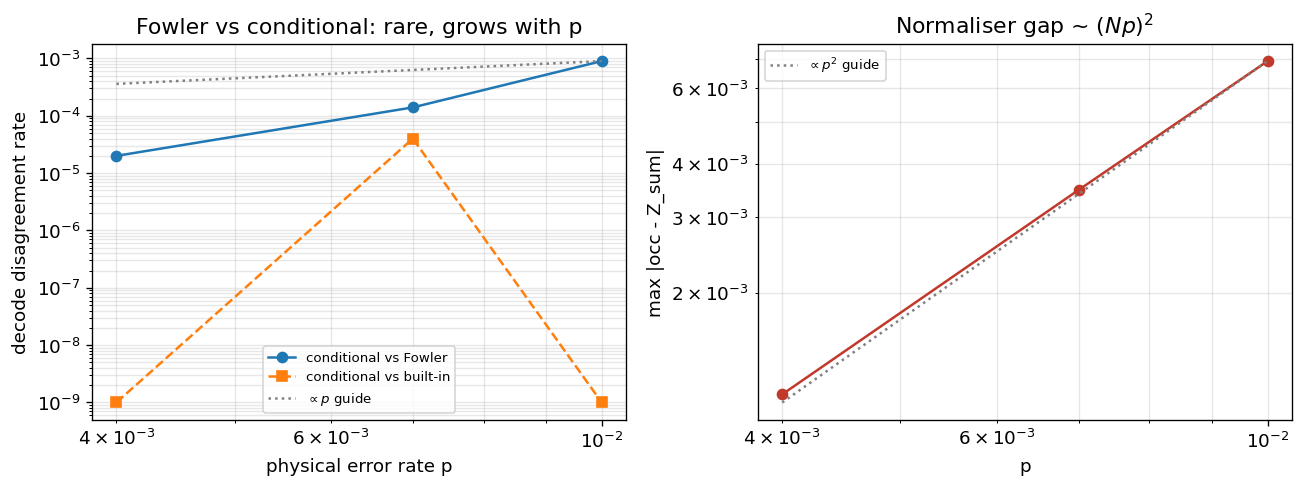

In [11]:
SWEEP_PS = [4e-3, 7e-3, 1e-2]
SWEEP_SHOTS = 50_000

rate_cf, rate_cb, occ_gap = [], [], []
for pp in SWEEP_PS:
    c2, d2, g2, m2, Z2, S2 = build_setup(D, pp, ROUNDS)
    dc = TwoPassCorrelatedMatching(d2, alpha=1.0, bypass_threshold=0, graph=g2)
    df = TwoPassCorrelatedMatching(d2, alpha=1.0, bypass_threshold=0, graph=g2,
                                   occ=Z2.astype(np.float32), corr=fowler_corr_array(g2, S2))
    cb = pymatching.Matching.from_detector_error_model(d2, enable_correlations=True)
    dt, _ = c2.compile_detector_sampler(seed=SEED).sample(shots=SWEEP_SHOTS, separate_observables=True)
    pc = dc.decode_batch(dt)[:, 0]; pf = df.decode_batch(dt)[:, 0]
    pb = cb.decode_batch(dt, enable_correlations=True, alpha=1.0)[:, 0]
    rate_cf.append(int((pc != pf).sum()) / SWEEP_SHOTS)
    rate_cb.append(int((pc != pb).sum()) / SWEEP_SHOTS)
    occ_gap.append(float(np.abs(g2.base_p - Z2).max()))
    print(f"p={pp:.0e}: cond-vs-Fowler={rate_cf[-1]:.2e}  cond-vs-builtin={rate_cb[-1]:.2e}  "
          f"|occ-Zsum|max={occ_gap[-1]:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(SWEEP_PS, np.maximum(rate_cf, 1e-9), "o-", label="conditional vs Fowler")
ax[0].loglog(SWEEP_PS, np.maximum(rate_cb, 1e-9), "s--", label="conditional vs built-in")
ref = np.array(SWEEP_PS) / SWEEP_PS[-1] * max(rate_cf)
ax[0].loglog(SWEEP_PS, ref, ":", color="gray", label="$\\propto p$ guide")
ax[0].set(xlabel="physical error rate p", ylabel="decode disagreement rate",
          title="Fowler vs conditional: rare, grows with p")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")

ax[1].loglog(SWEEP_PS, occ_gap, "o-", color="#c0392b")
ax[1].loglog(SWEEP_PS, np.array(SWEEP_PS)**2 / SWEEP_PS[-1]**2 * occ_gap[-1], ":", color="gray",
             label="$\\propto p^2$ guide")
ax[1].set(xlabel="p", ylabel="max |occ - Z_sum|", title="Normaliser gap ~ $(Np)^2$")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Conclusions

1. **Formula:** identical joint (`corr == S_both`); the only difference is the normaliser
   ($Z_\nu$ sum vs $\mathrm{occ}(\nu)$ odd-parity marginal), an $\mathcal{O}(p)$ relative effect with
   $P_\text{cond}\ge P_\text{fowler}$.
2. **Decode:** the difference is real but performance-negligible — rare near-tie flips (e.g. ~662/10⁶
   at $p=10^{-2}$, undetectable at $p\le2\times10^{-3}$) that cancel in LER. The built-in
   `enable_correlations` sides with the **conditional** (odd-parity marginal), so PyMatching's
   correlated matching *is* Fowler's, up to this negligible normaliser choice.
3. **Implication:** the reweight formula does **not** explain any PyMatching-vs-paper CM performance
   gap. Look instead to the error **decomposition** (coordinate-based Tesseract vs per-gate cylinders),
   the **noise model**, or the soft-evidence **alpha** (Fowler = hard evidence, $\alpha=1$).

See [`docs/fowler_vs_conditional_reweighting.md`](../docs/fowler_vs_conditional_reweighting.md) for the
full derivation and the high-statistics numbers.